# Visual Analysis & Model Insights for Final Report
Notebook này chứa đầy đủ các biểu đồ và số liệu phân tích chuyên sâu nhất để đưa vào báo cáo cuối kỳ (Mục 1, 2, 3).

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import xgboost as xgb
import os
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import cross_val_score

%matplotlib inline
sns.set(style="whitegrid", palette="muted")

## 1. Load Data and Models

In [27]:
# Load dữ liệu đã làm sạch và dữ liệu gốc
df = pd.read_csv('../data/data_for_assignment/cleaned_flight_data.csv')
raw_data = pd.read_csv('../data/IndianFlightdata - Sheet1.csv')

X = df.drop('Price', axis=1)
y = df['Price']

# Load mô hình Optimized XGBoost
best_xgb = xgb.XGBRegressor()
best_xgb.load_model('../models/best_flight_price_model_optimized.json')

# Load baseline để so sánh
try:
    baseline_rf = joblib.load('../models/rf_flight_price_model.pkl')
    has_baseline = True
except:
    has_baseline = False

print("Dữ liệu và mô hình đã sẵn sàng!")

Dữ liệu và mô hình đã sẵn sàng!


## 2. Thống kê làm sạch dữ liệu & Phân phối Giá vé
Chứng minh giá trị của bước tiền xử lý.

Số lượng dòng ban đầu: 10683
Số lượng dòng sau khi làm sạch: 10589
Tỷ lệ dữ liệu sạch: 99.12%


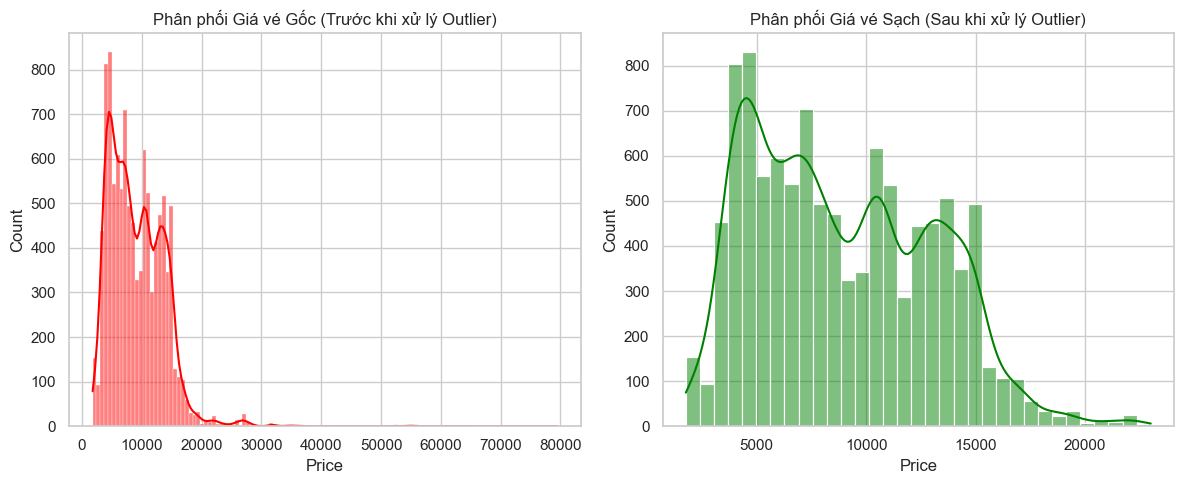

In [28]:
print(f"Số lượng dòng ban đầu: {len(raw_data)}")
print(f"Số lượng dòng sau khi làm sạch: {len(df)}")
print(f"Tỷ lệ dữ liệu sạch: {(len(df)/len(raw_data))*100:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(raw_data['Price'], kde=True, color='red')
plt.title('Phân phối Giá vé Gốc (Trước khi xử lý Outlier)')

plt.subplot(1, 2, 2)
sns.histplot(df['Price'], kde=True, color='green')
plt.title('Phân phối Giá vé Sạch (Sau khi xử lý Outlier)')

plt.tight_layout()
plt.show()

## 3. Phân tích Thị trường: Tỷ trọng Hãng bay
Biểu đồ to hơn và chi tiết hơn.

C:\Users\tanba\AppData\Local\Temp\ipykernel_27140\2220529083.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_counts.values, y=airline_counts.index, ax=ax[1], palette='viridis')


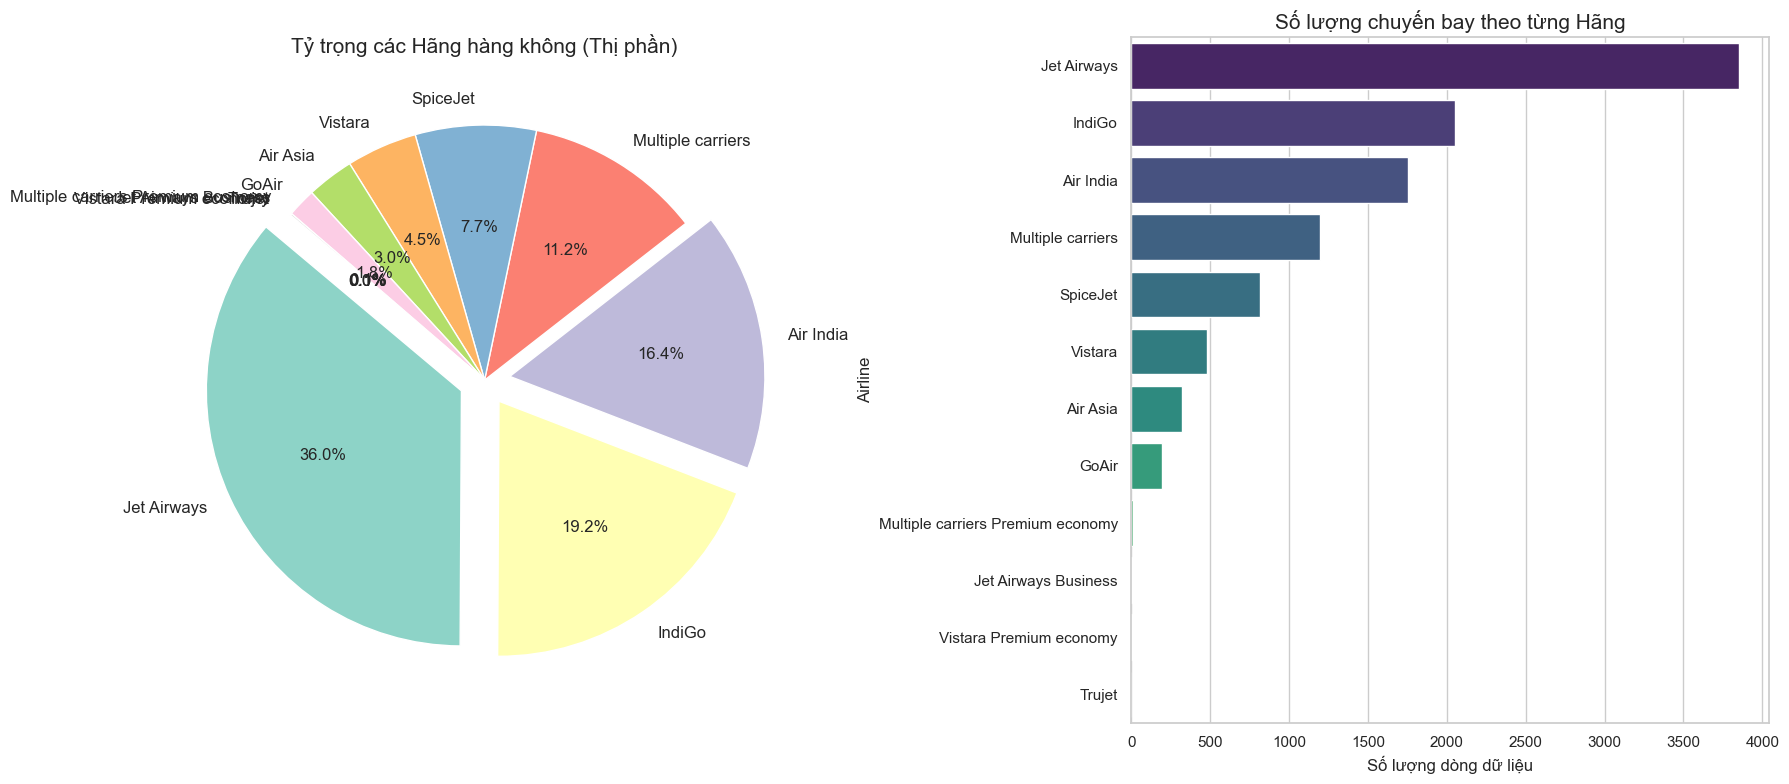

In [29]:
airline_counts = raw_data['Airline'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(18, 8))

# 1. Pie Chart lớn và rõ ràng
colors = sns.color_palette('Set3', len(airline_counts))
explode = [0.1 if i < 3 else 0 for i in range(len(airline_counts))]
ax[0].pie(airline_counts, labels=airline_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=explode, textprops={'fontsize': 12})
ax[0].set_title('Tỷ trọng các Hãng hàng không (Thị phần)', fontsize=15)

# 2. Bar Chart liệt kê chính xác số lượng
sns.barplot(x=airline_counts.values, y=airline_counts.index, ax=ax[1], palette='viridis')
ax[1].set_title('Số lượng chuyến bay theo từng Hãng', fontsize=15)
ax[1].set_xlabel('Số lượng dòng dữ liệu')

plt.tight_layout()
plt.show()

## 4. Ma trận tương quan (Correlation Heatmap)
Xem các yếu tố nào tỷ lệ thuận/nghịch với nhau.

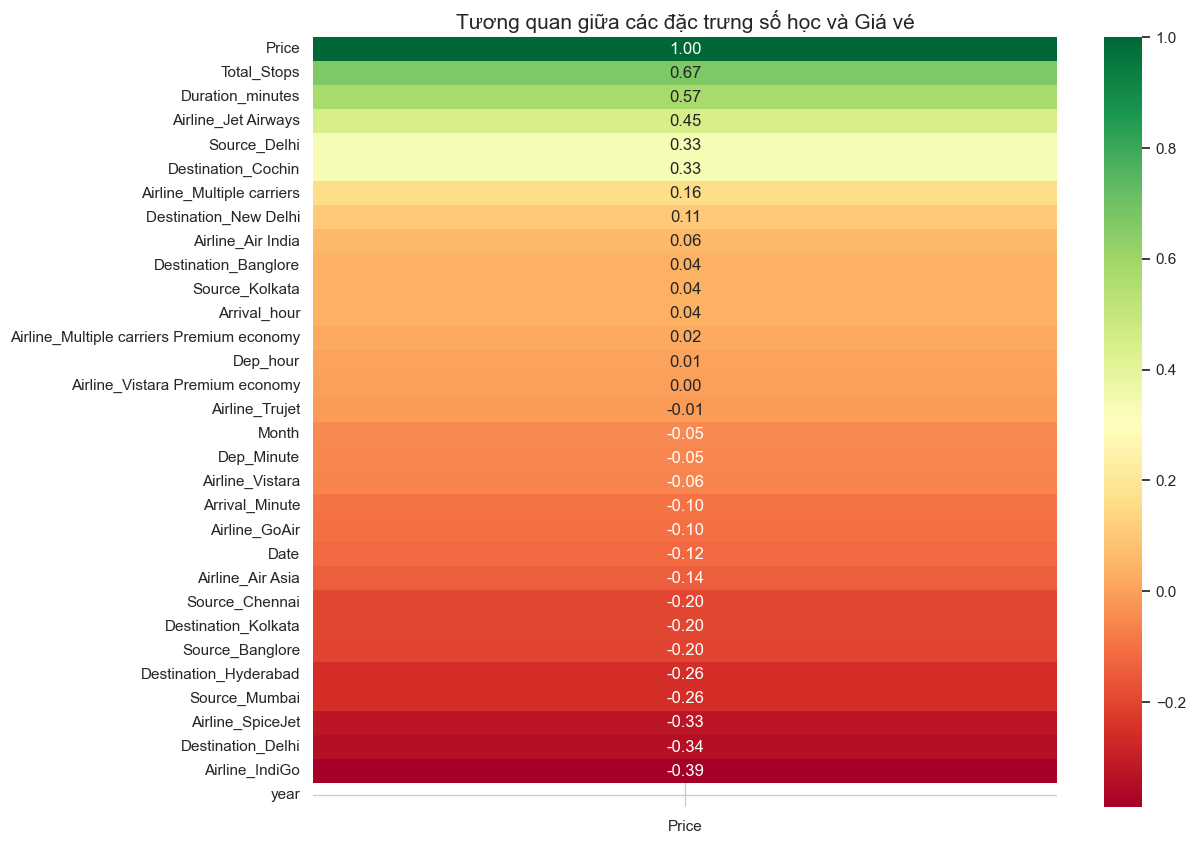

In [30]:
# Chỉ lấy các cột số học để tính tương quan
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['Price']].sort_values(by='Price', ascending=False), 
            annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Tương quan giữa các đặc trưng số học và Giá vé', fontsize=15)
plt.show()

## 5. Xu hướng thời gian & Số điểm dừng

C:\Users\tanba\AppData\Local\Temp\ipykernel_27140\3661466519.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Total_Stops', y='Price', palette='coolwarm')


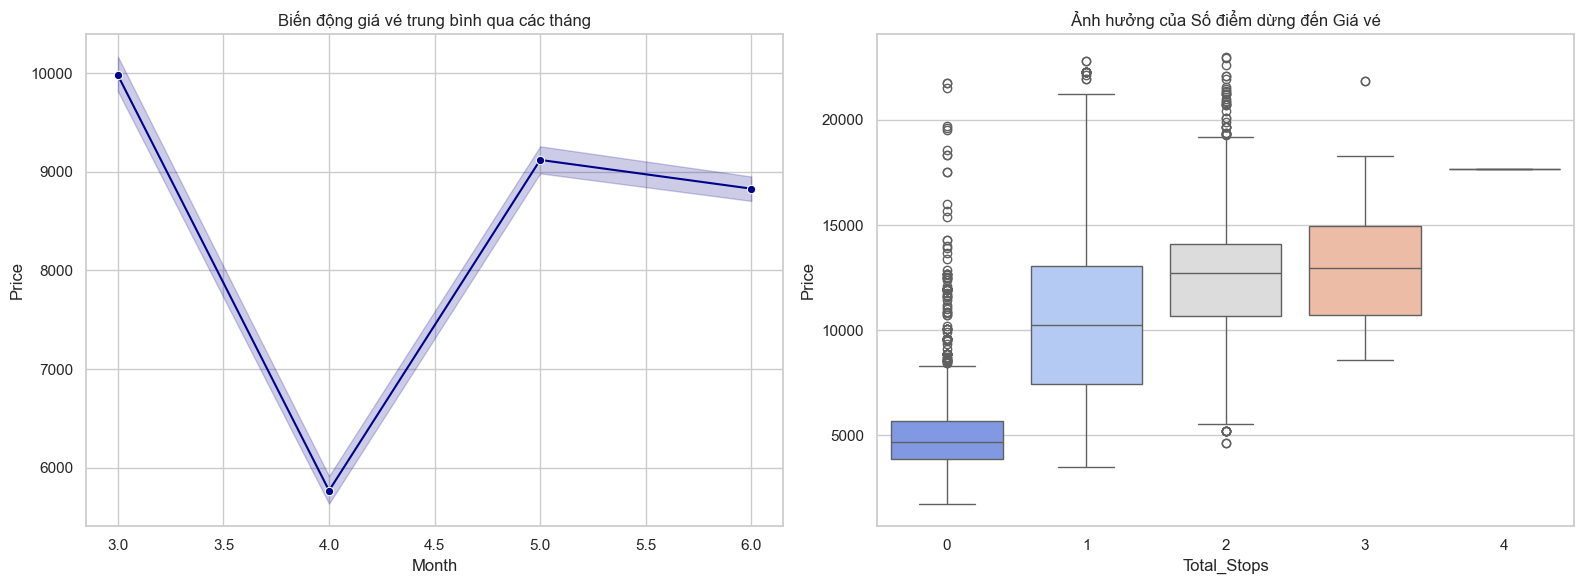

In [31]:
plt.figure(figsize=(16, 6))

# Theo tháng
plt.subplot(1, 2, 1)
sns.lineplot(data=df, x='Month', y='Price', marker='o', color='darkblue')
plt.title('Biến động giá vé trung bình qua các tháng')

# Theo số điểm dừng
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Total_Stops', y='Price', palette='coolwarm')
plt.title('Ảnh hưởng của Số điểm dừng đến Giá vé')

plt.tight_layout()
plt.show()

## 6. Hiệu suất mô hình & Tỷ lệ cải tiến

In [32]:
y_pred_xgb = best_xgb.predict(X)
r2_xgb = r2_score(y, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y, y_pred_xgb))

cv_scores = cross_val_score(best_xgb, X, y, cv=5, scoring='r2')

print(f"--- KẾT QUẢ MÔ HÌNH OPTIMIZED XGBOOST ---")
print(f"R2 Score: {r2_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"Cross-Validation R2 Mean: {cv_scores.mean():.4f}")

if has_baseline:
    y_pred_rf = baseline_rf.predict(X)
    rmse_rf = np.sqrt(mean_squared_error(y, y_pred_rf))
    improvement = ((rmse_rf - rmse_xgb) / rmse_rf) * 100
    print(f"Tỷ lệ cải tiến RMSE so với Baseline: {improvement:.2f}%")

--- KẾT QUẢ MÔ HÌNH OPTIMIZED XGBOOST ---
R2 Score: 0.8934
RMSE: 1328.28
Cross-Validation R2 Mean: 0.8540
Tỷ lệ cải tiến RMSE so với Baseline: -16.90%


## 7. Phân tích sai số (Residual Analysis)

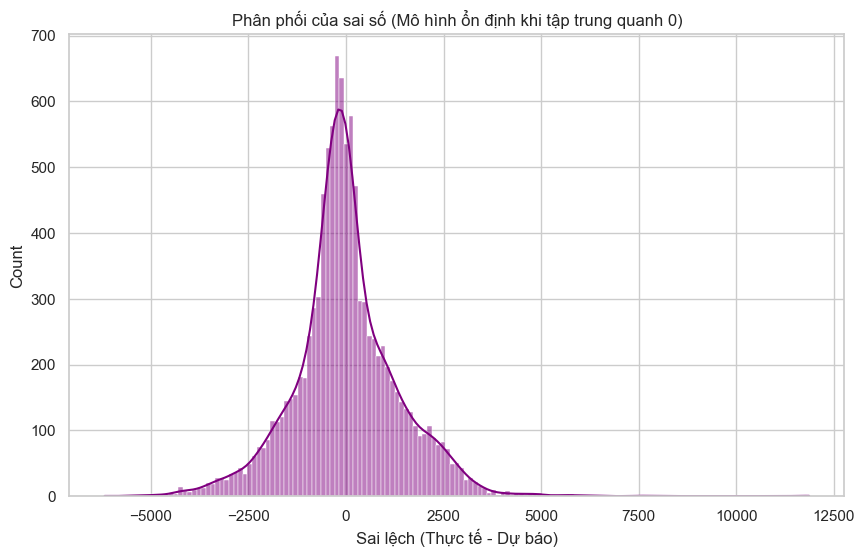

In [33]:
residuals = y - y_pred_xgb
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple')
plt.title('Phân phối của sai số (Mô hình ổn định khi tập trung quanh 0)')
plt.xlabel('Sai lệch (Thực tế - Dự báo)')
plt.show()

## 8. Độ quan trọng của đặc trưng (Feature Importance)

<Figure size 1000x800 with 0 Axes>

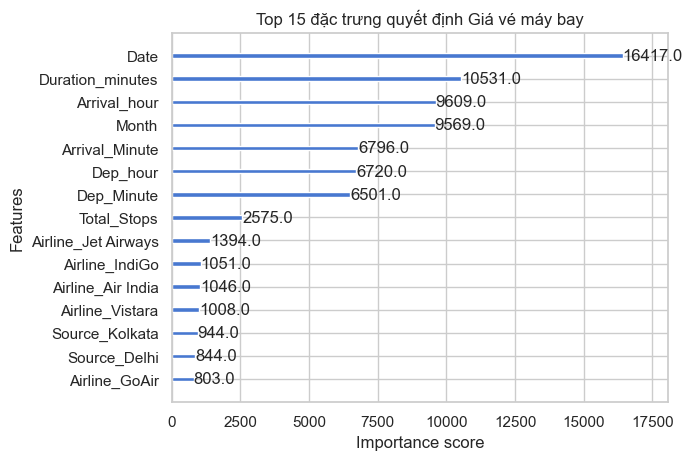

In [34]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb, max_num_features=15, importance_type='weight')
plt.title('Top 15 đặc trưng quyết định Giá vé máy bay')
plt.show()